# Eksperimen SML — Heart Disease Dataset
## Nama: Dea Zasqia Pasaribu Malau
## Dataset: Heart Disease (Prediksi Penyakit Jantung)

**Tujuan:** Memprediksi apakah seorang pasien memiliki penyakit jantung berdasarkan data klinis.
**Target:** `target` (0 = tidak ada penyakit jantung, 1 = ada penyakit jantung)


In [1]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

print("Library berhasil diimport!")
print(f"pandas: {pd.__version__} | numpy: {np.__version__}")


Library berhasil diimport!
pandas: 2.3.2 | numpy: 2.2.6


## 2. Data Loading

In [2]:
# Load dataset
df = pd.read_csv('../heart_disease_raw.csv')
print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")
df.head()


Shape: (1025, 14)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,0,131,512,0,1,157,1,2.2,1,1.0,3.0,1
1,57,0,1,196,525,0,1,166,1,3.7,0,2.0,6.0,1
2,43,0,3,143,475,1,1,145,0,1.7,1,2.0,6.0,0
3,71,0,3,156,421,0,2,124,1,0.2,1,0.0,7.0,1
4,36,0,3,194,383,0,0,158,1,4.6,0,0.0,3.0,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1015 non-null   float64
 12  thal      1015 non-null   float64
 13  target    1025 non-null   int64  
dtypes: float64(3), int64(11)
memory usage: 112.2 KB


## 3. Exploratory Data Analysis (EDA)

In [4]:
# 3.1 Missing Values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0])


Missing values:
ca      10
thal    10
dtype: int64


In [5]:
# 3.2 Statistik Deskriptif
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1025.0,52.484878,13.810309,29.0,41.0,53.0,64.0,76.0
sex,1025.0,0.472195,0.499470,0.0,0.0,0.0,1.0,1.0
cp,1025.0,1.488780,1.126787,0.0,0.0,1.0,3.0,3.0
trestbps,1025.0,145.581463,30.756914,94.0,118.0,144.0,174.0,199.0
chol,1025.0,342.960976,128.000269,126.0,232.0,339.0,453.0,563.0
fbs,1025.0,0.478049,0.499762,0.0,0.0,0.0,1.0,1.0
restecg,1025.0,1.024390,0.811532,0.0,0.0,1.0,2.0,2.0
thalach,1025.0,136.614634,38.459582,71.0,102.0,140.0,169.0,201.0
exang,1025.0,0.497561,0.500238,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,3.091024,1.797860,0.0,1.5,3.1,4.7,6.2


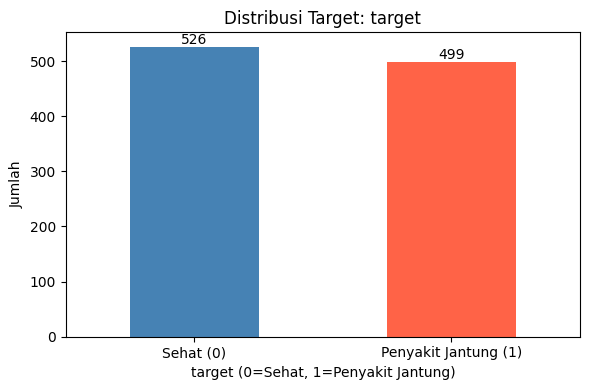

target
1    526
0    499
Name: count, dtype: int64


In [6]:
# 3.3 Distribusi Target
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Distribusi Target: target')
ax.set_xlabel('target (0=Sehat, 1=Penyakit Jantung)')
ax.set_ylabel('Jumlah')
ax.set_xticklabels(['Sehat (0)', 'Penyakit Jantung (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('eda_target_distribution.png')
plt.show()
print(df['target'].value_counts())


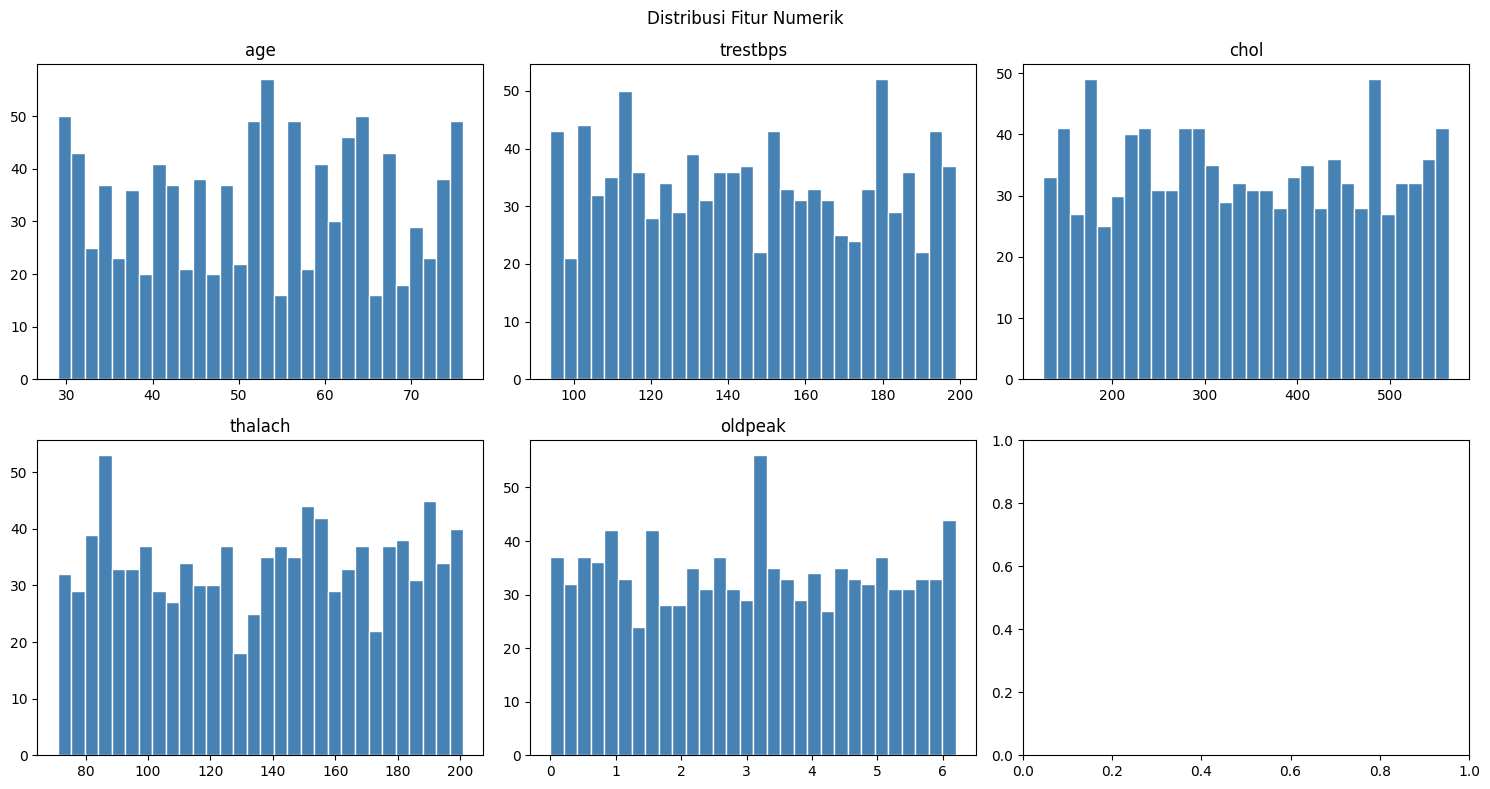

In [7]:
# 3.4 Distribusi Fitur Numerik
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.savefig('eda_numeric_distribution.png')
plt.show()


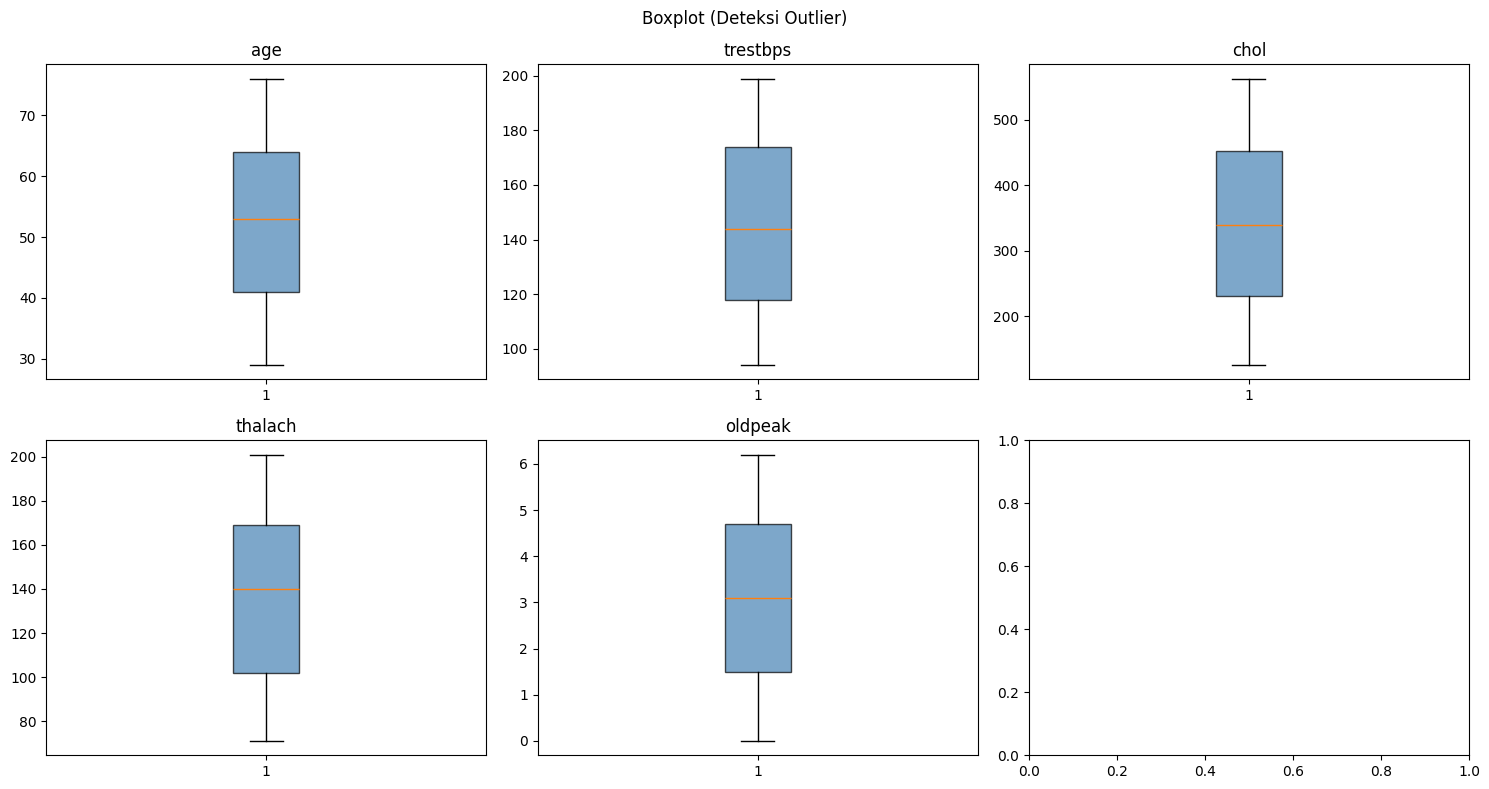

In [8]:
# 3.5 Boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
plt.suptitle('Boxplot (Deteksi Outlier)')
plt.tight_layout()
plt.savefig('eda_boxplot.png')
plt.show()


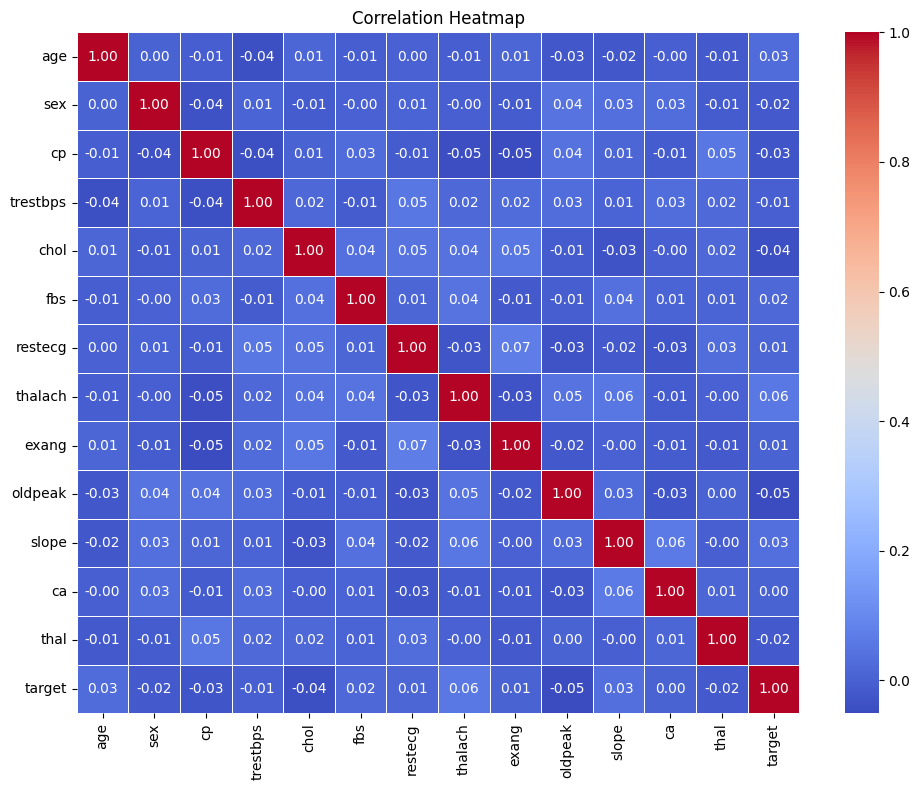

In [9]:
# 3.6 Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png')
plt.show()


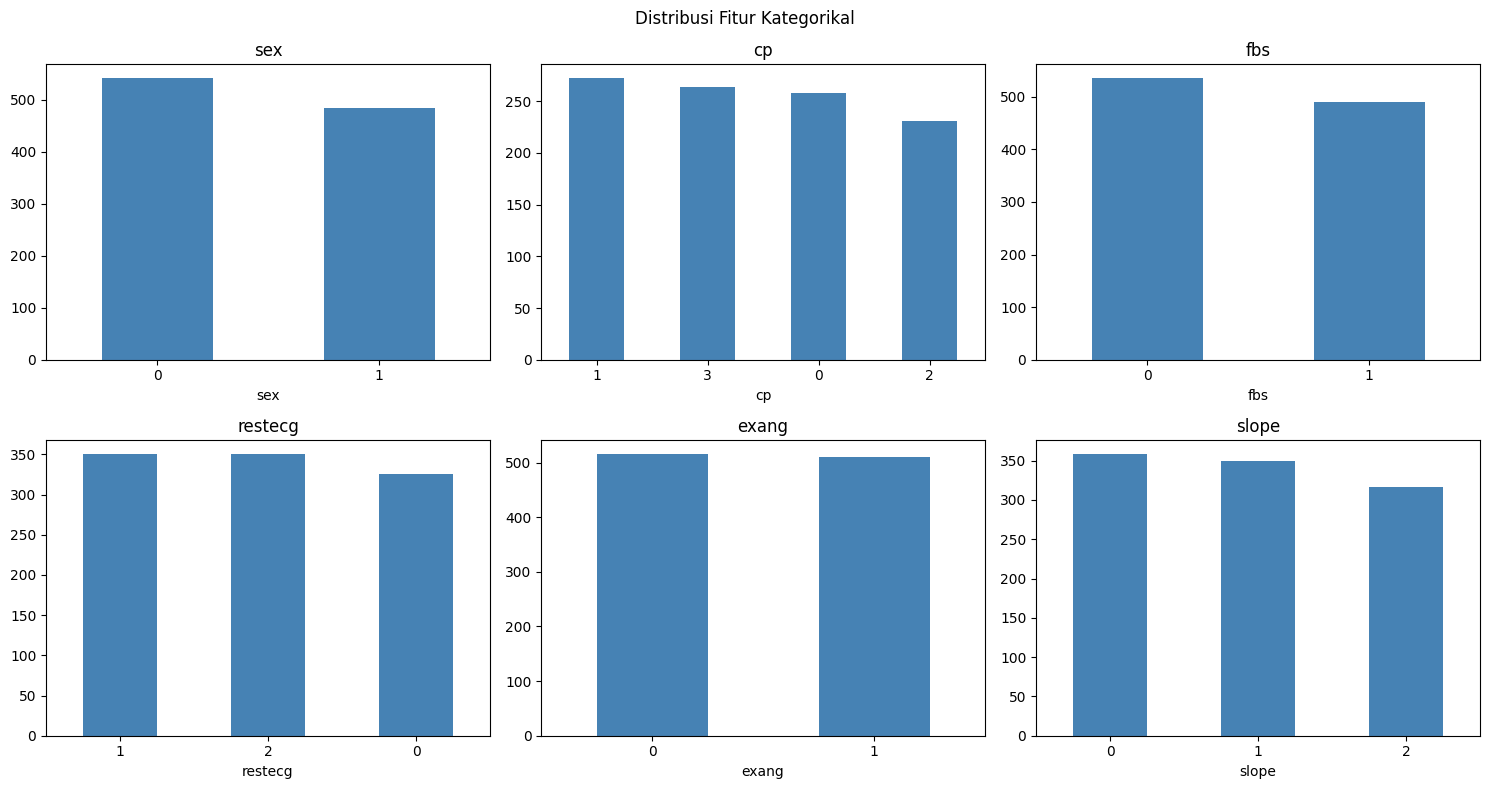

In [10]:
# 3.7 Distribusi Fitur Kategorikal
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=0)
plt.suptitle('Distribusi Fitur Kategorikal')
plt.tight_layout()
plt.savefig('eda_categorical_distribution.png')
plt.show()


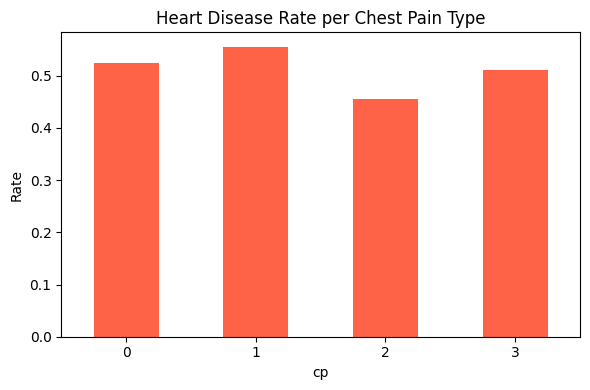

cp
0    0.523256
1    0.555147
2    0.454545
3    0.511364
Name: target, dtype: float64


In [11]:
# 3.8 Heart Disease Rate per Chest Pain Type
rate = df.groupby('cp')['target'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
rate.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Heart Disease Rate per Chest Pain Type')
ax.set_ylabel('Rate')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('eda_disease_rate.png')
plt.show()
print(rate)


## 4. Data Preprocessing

In [12]:
# 4.1 Handle Missing Values
df_clean = df.copy()
num_cols_all = df_clean.select_dtypes(include=np.number).columns
missing_cols = [c for c in num_cols_all if df_clean[c].isnull().any()]
if missing_cols:
    imputer = SimpleImputer(strategy='median')
    df_clean[missing_cols] = imputer.fit_transform(df_clean[missing_cols])
    print(f"Diimputasi (median): {missing_cols}")
print(f"Missing values setelah imputasi: {df_clean.isnull().sum().sum()}")


Diimputasi (median): ['ca', 'thal']
Missing values setelah imputasi: 0


In [13]:
# 4.2 Handle Duplicates
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Baris sebelum: {n_before} | Setelah: {len(df_clean)} | Hapus: {n_before - len(df_clean)}")


Baris sebelum: 1025 | Setelah: 1025 | Hapus: 0


In [14]:
# 4.3 Handle Outliers (IQR Capping)
outlier_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"{col:15s}: {n_out} outlier di-cap [{lower:.2f}, {upper:.2f}]")


age            : 0 outlier di-cap [6.50, 98.50]
trestbps       : 0 outlier di-cap [34.00, 258.00]
chol           : 0 outlier di-cap [-99.50, 784.50]
thalach        : 0 outlier di-cap [1.50, 269.50]
oldpeak        : 0 outlier di-cap [-3.30, 9.50]


In [15]:
# 4.4 Feature Scaling
X = df_clean.drop('target', axis=1)
y = df_clean['target']

scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
X = X.copy()
X[scale_cols] = scaler.fit_transform(X[scale_cols])
print(f"StandardScaler diterapkan pada: {scale_cols}")


StandardScaler diterapkan pada: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [16]:
# 4.5 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")


X_train: (820, 13) | X_test: (205, 13)
y_train: (820,) | y_test: (205,)


In [17]:
# 4.6 Simpan Dataset
import os
os.makedirs('heart_disease_preprocessing', exist_ok=True)

X_train.to_csv('heart_disease_preprocessing/X_train.csv', index=False)
X_test.to_csv('heart_disease_preprocessing/X_test.csv', index=False)
y_train.to_csv('heart_disease_preprocessing/y_train.csv', index=False)
y_test.to_csv('heart_disease_preprocessing/y_test.csv', index=False)

print("Dataset preprocessing tersimpan!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


Dataset preprocessing tersimpan!
X_train: (820, 13) | X_test: (205, 13)


## 5. Kesimpulan

| Tahap | Keterangan |
|-------|-----------|
| Data Loading | 1025 baris, 14 kolom |
| Missing Values | `ca` dan `thal` diimputasi dengan median |
| Duplikat | Tidak ada |
| Outlier | IQR capping pada 5 kolom numerik |
| Scaling | StandardScaler pada age, trestbps, chol, thalach, oldpeak |
| Split | 80% train (820), 20% test (205) dengan stratifikasi |
